The logistic regression model uses a linear function to assign an input $\mathbf{x}$ to one of two classes $y\in\{0,1\}$. For a 1D input, it has two parameters, $\phi_{0}$ and $\phi_{1}$, and is defined by:

\begin{equation}
Pr(y=1|x) = \textrm{sig}[\phi_{0}+\phi_{1}x],
\end{equation}

where~$\textrm{sig}[\bullet]$ is the logistic sigmoid function:

\begin{equation}
 \textrm{sig}[z] = \frac{1}{1+\exp[-z]}.
\end{equation}

\noindent (i) Plot $y$ against $x$ for this model for different values of $\phi_{0}$ and $\phi_{1}$ and explain the qualitative meaning of each parameter. (ii) What is a suitable loss function for this model? (iii) Compute the derivatives of this loss function with respect to the parameters. (iv) Generate ten data points from a normal distribution with mean -1 and standard deviation 1 and assign them the label~] $y=0$. Generate another ten data points from a normal distribution with mean 1 and standard deviation 1 and assign these the label $y=1$. Plot the loss as a heatmap in terms of the two parameters $\phi_{0}$ and $\phi_{1}$. (v) Is this loss function convex? How could you prove this?

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap

my_colormap_vals_hex =('2a0902', '2b0a03', '2c0b04', '2d0c05', '2e0c06', '2f0d07', '300d08', '310e09', '320f0a', '330f0b', '34100b', '35110c', '36110d', '37120e', '38120f', '39130f', '3a1410', '3b1411', '3c1511', '3d1612', '3e1613', '3f1713', '401714', '411814', '421915', '431915', '451a16', '461b16', '471b17', '481c17', '491d18', '4a1d18', '4b1e19', '4c1f19', '4d1f1a', '4e201b', '50211b', '51211c', '52221c', '53231d', '54231d', '55241e', '56251e', '57261f', '58261f', '592720', '5b2821', '5c2821', '5d2922', '5e2a22', '5f2b23', '602b23', '612c24', '622d25', '632e25', '652e26', '662f26', '673027', '683027', '693128', '6a3229', '6b3329', '6c342a', '6d342a', '6f352b', '70362c', '71372c', '72372d', '73382e', '74392e', '753a2f', '763a2f', '773b30', '783c31', '7a3d31', '7b3e32', '7c3e33', '7d3f33', '7e4034', '7f4134', '804235', '814236', '824336', '834437', '854538', '864638', '874739', '88473a', '89483a', '8a493b', '8b4a3c', '8c4b3c', '8d4c3d', '8e4c3e', '8f4d3f', '904e3f', '924f40', '935041', '945141', '955242', '965343', '975343', '985444', '995545', '9a5646', '9b5746', '9c5847', '9d5948', '9e5a49', '9f5a49', 'a05b4a', 'a15c4b', 'a35d4b', 'a45e4c', 'a55f4d', 'a6604e', 'a7614e', 'a8624f', 'a96350', 'aa6451', 'ab6552', 'ac6552', 'ad6653', 'ae6754', 'af6855', 'b06955', 'b16a56', 'b26b57', 'b36c58', 'b46d59', 'b56e59', 'b66f5a', 'b7705b', 'b8715c', 'b9725d', 'ba735d', 'bb745e', 'bc755f', 'bd7660', 'be7761', 'bf7862', 'c07962', 'c17a63', 'c27b64', 'c27c65', 'c37d66', 'c47e67', 'c57f68', 'c68068', 'c78169', 'c8826a', 'c9836b', 'ca846c', 'cb856d', 'cc866e', 'cd876f', 'ce886f', 'ce8970', 'cf8a71', 'd08b72', 'd18c73', 'd28d74', 'd38e75', 'd48f76', 'd59077', 'd59178', 'd69279', 'd7937a', 'd8957b', 'd9967b', 'da977c', 'da987d', 'db997e', 'dc9a7f', 'dd9b80', 'de9c81', 'de9d82', 'df9e83', 'e09f84', 'e1a185', 'e2a286', 'e2a387', 'e3a488', 'e4a589', 'e5a68a', 'e5a78b', 'e6a88c', 'e7aa8d', 'e7ab8e', 'e8ac8f', 'e9ad90', 'eaae91', 'eaaf92', 'ebb093', 'ecb295', 'ecb396', 'edb497', 'eeb598', 'eeb699', 'efb79a', 'efb99b', 'f0ba9c', 'f1bb9d', 'f1bc9e', 'f2bd9f', 'f2bfa1', 'f3c0a2', 'f3c1a3', 'f4c2a4', 'f5c3a5', 'f5c5a6', 'f6c6a7', 'f6c7a8', 'f7c8aa', 'f7c9ab', 'f8cbac', 'f8ccad', 'f8cdae', 'f9ceb0', 'f9d0b1', 'fad1b2', 'fad2b3', 'fbd3b4', 'fbd5b6', 'fbd6b7', 'fcd7b8', 'fcd8b9', 'fcdaba', 'fddbbc', 'fddcbd', 'fddebe', 'fddfbf', 'fee0c1', 'fee1c2', 'fee3c3', 'fee4c5', 'ffe5c6', 'ffe7c7', 'ffe8c9', 'ffe9ca', 'ffebcb', 'ffeccd', 'ffedce', 'ffefcf', 'fff0d1', 'fff2d2', 'fff3d3', 'fff4d5', 'fff6d6', 'fff7d8', 'fff8d9', 'fffada', 'fffbdc', 'fffcdd', 'fffedf', 'ffffe0')
my_colormap_vals_dec = np.array([int(element,base=16) for element in my_colormap_vals_hex])
r = np.floor(my_colormap_vals_dec/(256*256))
g = np.floor((my_colormap_vals_dec - r *256 *256)/256)
b = np.floor(my_colormap_vals_dec - r * 256 *256 - g * 256)
my_colormap = ListedColormap(np.vstack((r,g,b)).transpose()/255.0)

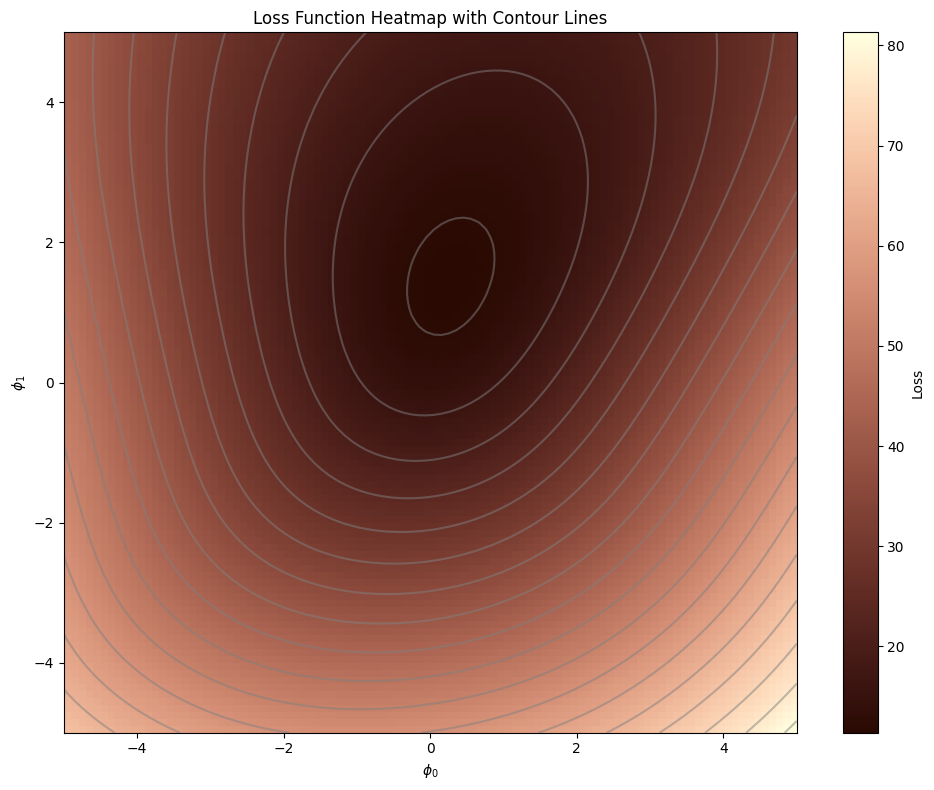

In [5]:
import numpy as np
import matplotlib.pyplot as plt
# my_colormap is available from the previous cell

# 1. Define the sigmoid function
def sig(z):
    return 1 / (1 + np.exp(-z))

# 2. Define the logistic regression probability
def pr_y_1_given_x(x, phi0, phi1):
    return sig(phi0 + phi1 * x)

# 3. Generate data points
np.random.seed(42) # for reproducibility
n_samples = 10
x_neg = np.random.normal(loc=-1, scale=1, size=n_samples)
y_neg = np.zeros(n_samples)
x_pos = np.random.normal(loc=1, scale=1, size=n_samples)
y_pos = np.ones(n_samples)

x_data = np.concatenate((x_neg, x_pos))
y_data = np.concatenate((y_neg, y_pos))

# 4. Define the loss function (Binary Cross-Entropy)
def binary_cross_entropy_loss(phi0, phi1, x_data, y_data):
    predictions = pr_y_1_given_x(x_data, phi0, phi1)
    # Ensure numerical stability for log
    predictions = np.clip(predictions, 1e-10, 1 - 1e-10)
    loss = -np.sum(y_data * np.log(predictions) + (1 - y_data) * np.log(1 - predictions))
    return loss

# 5. Create a grid of parameters and calculate loss
phi0_range = np.linspace(-5, 5, 100)
phi1_range = np.linspace(-5, 5, 100)
PHI0, PHI1 = np.meshgrid(phi0_range, phi1_range)
LOSS = np.zeros_like(PHI0)

for i in range(PHI0.shape[0]):
    for j in range(PHI0.shape[1]):
        LOSS[i, j] = binary_cross_entropy_loss(PHI0[i, j], PHI1[i, j], x_data, y_data)

# 6. Plot the heatmap with contours for display and SVG save
fig_main_plot, ax_main_plot = plt.subplots(figsize=(10, 8))
heatmap_main = ax_main_plot.imshow(LOSS, origin='lower', extent=[phi0_range.min(), phi0_range.max(), phi1_range.min(), phi1_range.max()],
                                    cmap=my_colormap, aspect='auto')
plt.colorbar(heatmap_main, ax=ax_main_plot, label='Loss')
ax_main_plot.contour(PHI0,PHI1,LOSS,20,colors=['#80808080'])

ax_main_plot.clabel(contours_main, inline=True, fontsize=8, fmt='%1.1f')

ax_main_plot.set_xlabel(r'$\phi_0$')
ax_main_plot.set_ylabel(r'$\phi_1$')
ax_main_plot.set_title('Loss Function Heatmap with Contour Lines')
plt.tight_layout()

# Save the figure with heatmap and contours as an SVG
# This is the "figure without the rgb image" in the sense of a vector-based plot.
fig_main_plot.savefig('loss_function_heatmap_contours.svg', format='svg')

# 7. Save just the RGB image (heatmap) as a PNG
# This figure will only contain the heatmap pixels, no axes, labels, or colorbar.
fig_rgb_png, ax_rgb_png = plt.subplots(figsize=(10, 8), frameon=False)
ax_rgb_png.imshow(LOSS, origin='lower', extent=[phi0_range.min(), phi0_range.max(), phi1_range.min(), phi1_range.max()],
                   cmap=my_colormap, aspect='auto')
ax_rgb_png.axis('off') # Turn off axes
plt.tight_layout(pad=0) # Remove padding
fig_rgb_png.savefig('loss_heatmap_rgb.png', bbox_inches='tight', pad_inches=0, dpi=300)
plt.close(fig_rgb_png) # Close this figure so it's not displayed

plt.show() # Display the main plot with heatmap and contours to the user